In [7]:
# Your code here
# %pip install sqlalchemy
from sqlalchemy import create_engine, MetaData, Table, Column, Integer, Float, String, ForeignKey, select #make database connection
from sqlalchemy.orm import declarative_base, relationship, sessionmaker
from pathlib import Path

In [8]:
# create database file
dbPath = 'spendermender.db' #name of database file
Path(dbPath).parent.mkdir(parents=True, exist_ok=True)
Path(dbPath).touch()

In [9]:
engine = create_engine('sqlite:///%s' % dbPath) #Use SQLAlchemy to connect to a SQLite database
#SQLAlchemy uses SQLite
#SQLite = storage (database)
#SQLAlchemy = translator (Python → database)

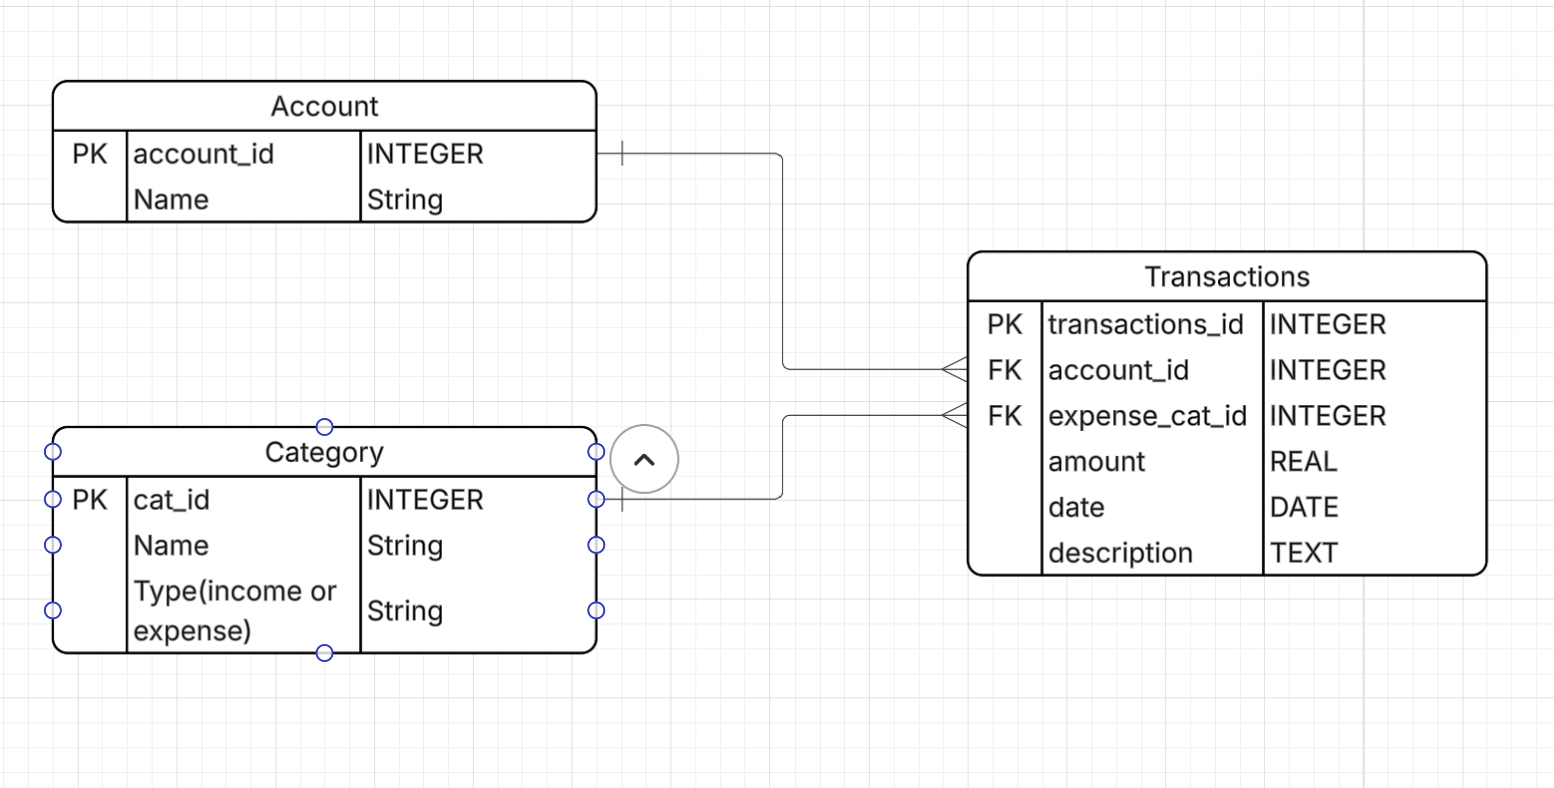

In [10]:
metadata = MetaData()
Base = declarative_base()

class Account(Base): # maps to table
    __tablename__ = "account" # Not a private object
    account_id = Column(Integer, primary_key=True) # Attributes are columns # Objects will be rows
    name = Column(String, nullable=False)
    # relationship
    transactions = relationship("Transaction", back_populates="account") # An account can have multiple transactions
#This class represents a database table
#Each class instance becomes one row

class Category(Base): # maps to table
    __tablename__ = "category" # Not a private object
    cat_id = Column(Integer, primary_key=True) # Attributes are columns # Objects will be rows
    cat_type = Column(String, nullable=False) 
    # relationship
    transactions = relationship("Transaction", back_populates="category") # Category can have multiple transactions?
    
class Transaction(Base): # maps to table
    __tablename__ = "transaction" # Not a private object
    transaction_id = Column(Integer, primary_key=True) # Attributes are columns # Objects will be rows
    account_id = Column(Integer, ForeignKey("account.account_id"))
    cat_id = Column(Integer, ForeignKey("category.cat_id"))
    amount = Column(Float, nullable=False)
    date = Column(String, nullable=False)
    description = Column(String)
    # relationship               
    account = relationship("Account", back_populates="transactions") # each transaction only has one account
    category = relationship("Category", back_populates="transactions") # each transaction only has one category



In [11]:
Session = sessionmaker(bind=engine) #session lets us talk to the database
session = Session()
Base.metadata.create_all(engine) #creates the table inside the database file. Without it, the table only exists in memory not in the database.

In [12]:
# Create 2 accounts
# For now we will have accounts belonging to multiple people in the same database
account1 = Account(name="Heather Ho")
account2 = Account(name="Solhee Tucker")

session.add_all([account1, account2])
session.commit()

# Creating categories: Admin will create a set of categories but users can add more categories later
cat1 = Category(cat_type="Dining")
cat2 = Category(cat_type="Rent")
cat3 = Category(cat_type="Transportion")
cat4 = Category(cat_type="Groceries")

session.add_all([cat1, cat2, cat3, cat4])
session.commit()

# Creating transactions
transaction1 = Transaction(account_id=1, cat_id=1, amount=10.0, date="01/03/2026", description="Subway")
transaction2 = Transaction(account_id=1, cat_id=3, amount=40.50, date="03/04/2026", description="gas")
transaction3 = Transaction(account_id=2, cat_id=4, amount=89.10, date="04/19/2026",description="Safeway")

session.add_all([transaction1, transaction2, transaction3])
session.commit()